In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain
from scipy.stats import zscore
import scipy.sparse as sp
import pynetcor as pnc
from pynetcor.cor import cor_topk
import multiprocessing
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import plotly.graph_objects as go

In [2]:
# ------------------------------
# Set dataPaths
# ------------------------------
gse_expressionPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/01GeneMatrix_gse102556-08052025.csv.gz"
uth_expressionPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/01GeneMatrix_uthealth-08182025.csv.gz"
vaa_expressionPath = 'C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/01transcriptome/00data/00vabb_genecounts-08152025.csv.gz'

In [3]:
# ------------------------------
# Load Datasets
# ------------------------------
gse = pd.read_csv(gse_expressionPath, index_col = 0)
uth = pd.read_csv(uth_expressionPath, index_col = 0)
vaa = pd.read_csv(vaa_expressionPath, index_col = 0)

print("UTHealth data:", gse.shape)
print("GSE data:", uth.shape)
print("VABB data:", vaa.shape)

UTHealth data: (57773, 96)
GSE data: (25438, 89)
VABB data: (60605, 551)


In [4]:
# ------------------------------
# Add the filter for the genes in the Clocks
# ------------------------------
clockgenesP = 'C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/03merged_genes-08212025.csv'
clockgenes = pd.read_csv(clockgenesP)

In [5]:
# ------------------------------
# Filter genes in clocks
# ------------------------------
# get unique Ensembl IDs from the annotation dataframe
ensembl_keep = clockgenes['Ensembl'].unique()
# filter expression matrices
uth_filtered = uth.loc[uth.index.intersection(ensembl_keep)]
gse_filtered = gse.loc[gse.index.intersection(ensembl_keep)]
vaa_filtered = vaa.loc[vaa.index.intersection(ensembl_keep)]

print("UTHealth data:", uth_filtered.shape)
print("GSE data:", gse_filtered.shape)
print("VABB data:", vaa_filtered.shape)

UTHealth data: (18261, 89)
GSE data: (17754, 96)
VABB data: (18103, 551)


In [6]:
# ------------------------------
# Find common genes across all datasets
# ------------------------------
common_genes = set(uth_filtered.index) & set(gse_filtered.index) & set(vaa_filtered.index)
print("Genes in all datasets:", len(common_genes))
uth_final = uth_filtered.loc[uth_filtered.index.intersection(common_genes)]
gse_final = gse_filtered.loc[gse_filtered.index.intersection(common_genes)]
vaa_final = vaa_filtered.loc[vaa_filtered.index.intersection(common_genes)]

print("UTHealth:", uth_final.shape)
print("GSE:", gse_final.shape)
print("VABB:", vaa_final.shape)

Genes in all datasets: 17663
UTHealth: (17663, 89)
GSE: (17663, 96)
VABB: (17663, 551)


In [7]:
# ------------------------------
# Define a function to z-score the genes
# ------------------------------
def zscore(df):
    """Row-wise z-score, skipping genes with zero variance."""
    df = df.copy()
    row_std = df.std(axis=1)
    keep = row_std > 0  # avoid division by zero
    df = df.loc[keep]
    return ((df.T - df.mean(axis=1)) / df.std(axis=1)).T

In [8]:
# ------------------------------
# Z-score the expression matrix
# ------------------------------
uth_z = zscore(uth_final)
gse_z = zscore(gse_final)
vaa_z = zscore(vaa_final)
print("UTHealth:", uth_z.shape)
print("GSE:", gse_z.shape)
print("VABB:", vaa_z.shape)

# ------------------------------
# Find common genes across all datasets
# ------------------------------
common_genes = set(uth_z.index) & set(gse_z.index) & set(vaa_z.index)
print("Genes in all datasets:", len(common_genes))
uth_z = uth_z.loc[uth_z.index.intersection(common_genes)]
gse_z = gse_z.loc[gse_z.index.intersection(common_genes)]
vaa_z = vaa_z.loc[vaa_z.index.intersection(common_genes)]
print("UTHealth:", uth_z.shape)
print("GSE:", gse_z.shape)
print("VABB:", vaa_z.shape)

UTHealth: (17578, 89)
GSE: (17405, 96)
VABB: (17515, 551)
Genes in all datasets: 17308
UTHealth: (17308, 89)
GSE: (17308, 96)
VABB: (17308, 551)


In [17]:
# ---------------------------------------------
# Define a function for a correlation network
# ---------------------------------------------
def compute_correlation_network_pynetcor_topk(expr_df, method='pearson', transpose=True):
    """
    Computes a gene-gene correlation network using pyNetCor.
    
    Parameters:
    -----------
    expr_df : pd.DataFrame
        Expression matrix (genes x samples)
    method : str
        Correlation method: 'pearson', 'spearman', or 'kendall'
    topk : int or None
        If specified, only returns the top-k correlations per gene.
    transpose : bool
        If True, transpose expr_df to shape (genes x samples)
    
    Returns:
    --------
    edges_df : pd.DataFrame
        Edge list with columns ['Gene1', 'Gene2', 'Correlation']
    """
    n_threads = max(1, multiprocessing.cpu_count() - 1)
    expr = expr_df.T if transpose else expr_df.copy()
    
    # Compute correlations
    topk = expr.shape[1] - 1  # for full correlations
    # Warm-up the library
    _ = cor_topk(expr.values, method='pearson', threads=n_threads, k=topk)
    corr_results = cor_topk(expr.values, method=method, threads=n_threads, k=topk)

    # Ensure results have correct shape
    if corr_results.shape[1] != 4:
        raise ValueError(f"Expected corr_results with 4 columns, got {corr_results.shape[1]}")
    
    # corr_results shape: (num_edges, 4): [gene1_idx, gene2_idx, correlation, pval]
    edges_df = pd.DataFrame({
        "Gene1": [expr.columns[int(i)] for i in corr_results[:,0]],
        "Gene2": [expr.columns[int(i)] for i in corr_results[:,1]],
        "Correlation": corr_results[:,2],
        "Pval": corr_results[:,3]
    })
    
    return edges_df

In [22]:
# ---------------------------------------------
# Compute the correlation network
# ---------------------------------------------
# The script will Transpose the matrix, (gene x samples) are the requiered input
edges1 = compute_correlation_network_pynetcor_topk(uth_z)
edges2 = compute_correlation_network_pynetcor_topk(gse_z)
edges3 = compute_correlation_network_pynetcor_topk(vaa_z)

# WARNING: pyNetCor uses several threads and need to be step ran several times the same step; to get stable results

In [26]:
# ---------------------------
# Strict consensus network
# ---------------------------
def consensus_edges(edge_dfs, min_agreement=2, corr_threshold=0.2):
    """
    edge_dfs: list of DataFrames with columns ['Gene1','Gene2','Correlation']
    min_agreement: minimum number of datasets where edge must appear
    corr_threshold: minimum absolute correlation to consider
    """
    # Keep edges above correlation threshold
    filtered_edges = []
    for df in edge_dfs:
        filtered = df[abs(df['Correlation']) >= corr_threshold].copy()
        # Make a consistent identifier for edge (unordered)
        filtered['edge'] = filtered.apply(lambda x: tuple(sorted([x['Gene1'], x['Gene2']])), axis=1)
        filtered_edges.append(filtered)
    
    # Count edge occurrences
    all_edges = pd.concat(filtered_edges)
    edge_counts = all_edges['edge'].value_counts()
    
    # Keep edges appearing in at least min_agreement datasets
    consensus_edges_list = edge_counts[edge_counts >= min_agreement].index.tolist()
    
    # Build consensus DataFrame with average correlation
    consensus_rows = []
    for edge in consensus_edges_list:
        corrs = []
        for df in filtered_edges:
            mask = df['edge'] == edge
            if mask.any():
                corrs.append(df.loc[mask, 'Correlation'].values[0])
        avg_corr = np.mean(corrs)
        consensus_rows.append((edge[0], edge[1], avg_corr))
    
    consensus_df = pd.DataFrame(consensus_rows, columns=['Gene1','Gene2','AvgCorrelation'])
    return consensus_df

# ---------------------------
# Computation
# ---------------------------
consensus_df = consensus_edges([edges1, edges2, edges3], min_agreement=2, corr_threshold=0.2)
print("Consensus edges:", consensus_df.shape[0])

Consensus edges: 16170


In [27]:
# ---------------------------
# RWR-based consensus network
# ---------------------------
def rwr_consensus(edge_dfs, alpha=0.7, max_iter=100, tol=1e-6):
    """
    Build networks for each edge DataFrame, run RWR, and combine node scores.
    Returns: dict of node -> consensus score
    """
    node_scores = {}
    graphs = []
    
    # Build graphs
    for df in edge_dfs:
        G = nx.Graph()
        edges = [(row['Gene1'], row['Gene2'], row['Correlation']) 
                 for _, row in df.iterrows() if abs(row['Correlation']) >= 0.2]
        G.add_weighted_edges_from(edges)
        graphs.append(G)
    
    # Random Walk with Restart
    for G in graphs:
        nodes = list(G.nodes())
        A = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
        # Normalize adjacency
        P = A / A.sum(axis=1, keepdims=True)
        r = np.ones(len(nodes)) / len(nodes)  # initial probability
        r_prev = np.zeros(len(nodes))
        for _ in range(max_iter):
            r_new = alpha * P.T @ r + (1 - alpha) * r
            if np.linalg.norm(r_new - r_prev, 1) < tol:
                break
            r_prev = r_new
        # Accumulate scores
        for i, node in enumerate(nodes):
            node_scores[node] = node_scores.get(node, 0) + r_new[i]
    
    # Average scores across networks
    for node in node_scores:
        node_scores[node] /= len(graphs)
    
    return node_scores

# ---------------------------
# Example usage
# ---------------------------
rwr_scores = rwr_consensus([edges1, edges2, edges3], alpha=0.7)
# Convert all RWR scores to DataFrame
all_genes_df = pd.DataFrame(rwr_scores.items(), columns=['Gene', 'RWR_score'])
# Sort by RWR_score descending
all_genes_df = all_genes_df.sort_values('RWR_score', ascending=False).reset_index(drop=True)
print(all_genes_df.head(20))

               Gene  RWR_score
0   ENSG00000084072   0.569317
1   ENSG00000122481   0.520258
2   ENSG00000185436   0.513991
3   ENSG00000204138   0.510080
4   ENSG00000181773   0.505499
5   ENSG00000116288   0.504032
6   ENSG00000127125   0.498233
7   ENSG00000142661   0.491267
8   ENSG00000158195   0.488124
9   ENSG00000162572   0.485499
10  ENSG00000162434   0.484310
11  ENSG00000198746   0.476196
12  ENSG00000116786   0.475793
13  ENSG00000159339   0.474791
14  ENSG00000188641   0.474016
15  ENSG00000137941   0.473374
16  ENSG00000171621   0.472136
17  ENSG00000116455   0.471842
18  ENSG00000185668   0.456428
19  ENSG00000137936   0.454866


In [28]:
# ---------------------------
# Compute thresholds (95th percentile for RWR score)
# ---------------------------
# Compute 95th percentile of RWR_score
threshold_95 = np.percentile(all_genes_df['RWR_score'], 95)
# Create a new column labeling Above/Below 95th percentile
all_genes_df['RWR_score_95th'] = np.where(all_genes_df['RWR_score'] >= threshold_95, "Above", "Below")
# Optional: filter only top genes
top_genes_95th = all_genes_df[all_genes_df['RWR_score_95th'] == "Above"]
print(top_genes_95th)

               Gene  RWR_score RWR_score_95th
0   ENSG00000084072   0.569317          Above
1   ENSG00000122481   0.520258          Above
2   ENSG00000185436   0.513991          Above
3   ENSG00000204138   0.510080          Above
4   ENSG00000181773   0.505499          Above
5   ENSG00000116288   0.504032          Above
6   ENSG00000127125   0.498233          Above
7   ENSG00000142661   0.491267          Above
8   ENSG00000158195   0.488124          Above
9   ENSG00000162572   0.485499          Above
10  ENSG00000162434   0.484310          Above
11  ENSG00000198746   0.476196          Above
12  ENSG00000116786   0.475793          Above
13  ENSG00000159339   0.474791          Above
14  ENSG00000188641   0.474016          Above
15  ENSG00000137941   0.473374          Above
16  ENSG00000171621   0.472136          Above
17  ENSG00000116455   0.471842          Above
18  ENSG00000185668   0.456428          Above
19  ENSG00000137936   0.454866          Above
20  ENSG00000011021   0.452533    

In [29]:
# ---------------------------
# GRIN-style RWR consensus
# ---------------------------
def grin_rwr_consensus(edge_dfs, alpha=0.7, max_iter=100, tol=1e-6, seeds=None):
    """
    edge_dfs: list of DataFrames with columns ['Gene1','Gene2','Correlation']
    alpha: RWR restart probability
    max_iter: max iterations for RWR
    tol: convergence tolerance
    seeds: optional list of seed genes; if None, uniform initialization
    Returns: dict of node -> consensus RWR score
    """
    node_scores = {}
    graphs = []

    # Build networks
    for df in edge_dfs:
        G = nx.Graph()
        edges = [(row['Gene1'], row['Gene2'], row['Correlation'])
                 for _, row in df.iterrows() if abs(row['Correlation']) >= 0.2]
        G.add_weighted_edges_from(edges)
        graphs.append(G)

    # RWR on each network
    for G in graphs:
        nodes = list(G.nodes())
        A = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
        
        # Normalize adjacency to row-stochastic matrix
        P = A / A.sum(axis=1, keepdims=True)
        
        # Initialize probability vector
        if seeds is None:
            r = np.ones(len(nodes)) / len(nodes)
        else:
            r = np.zeros(len(nodes))
            for i, node in enumerate(nodes):
                if node in seeds:
                    r[i] = 1.0 / len(seeds)
        r_prev = np.zeros(len(nodes))

        # RWR iterations
        for _ in range(max_iter):
            r_new = alpha * P.T @ r + (1 - alpha) * r
            if np.linalg.norm(r_new - r_prev, 1) < tol:
                break
            r_prev = r_new

        # Accumulate scores
        for i, node in enumerate(nodes):
            node_scores[node] = node_scores.get(node, 0) + r_new[i]

    # Average across networks
    for node in node_scores:
        node_scores[node] /= len(graphs)

    # Return sorted DataFrame
    scores_df = pd.DataFrame.from_dict(node_scores, orient='index', columns=['RWR_score'])
    scores_df.sort_values('RWR_score', ascending=False, inplace=True)
    return scores_df

# ---------------------------
# Example usage
# ---------------------------
grin_scores = grin_rwr_consensus([edges1, edges2, edges3], alpha=0.7)
print(grin_scores)

                 RWR_score
ENSG00000084072   0.569317
ENSG00000122481   0.520258
ENSG00000185436   0.513991
ENSG00000204138   0.510080
ENSG00000181773   0.505499
...                    ...
ENSG00000143631  -0.616279
ENSG00000143556  -0.623804
ENSG00000143458  -0.637468
ENSG00000203783  -0.657066
ENSG00000117362  -1.017756

[905 rows x 1 columns]


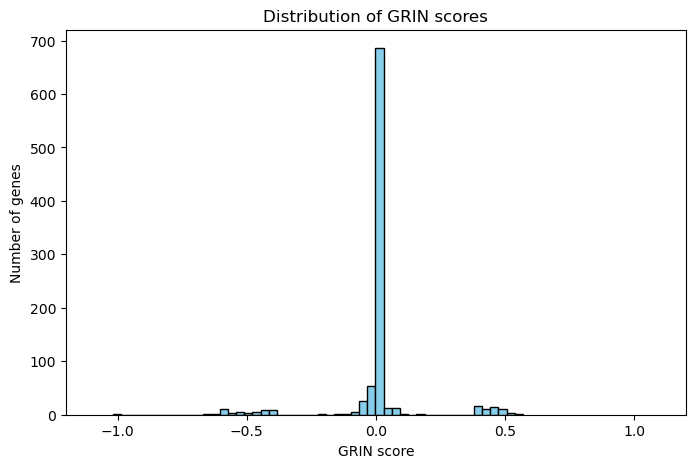

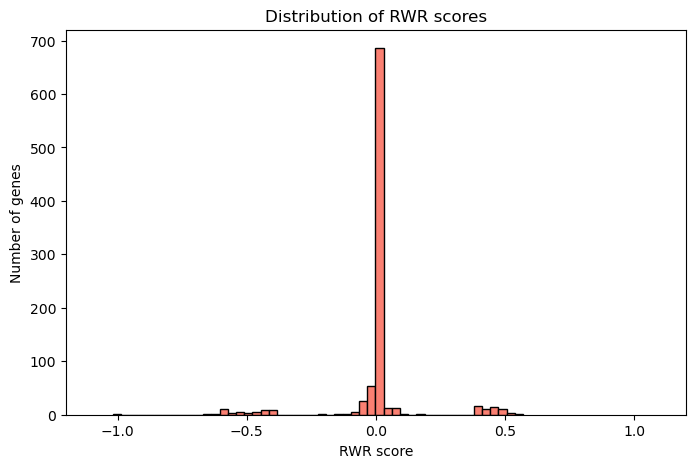

In [30]:
# Assuming `grin_scores` and `all_genes_df` are your DataFrames
# grin_scores: DataFrame with column 'GRIN_score'
# all_genes_df: DataFrame with column 'RWR_score'

# Histogram of GRIN scores
plt.figure(figsize=(8, 5))
plt.hist(grin_scores['RWR_score'], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of GRIN scores")
plt.xlabel("GRIN score")
plt.ylabel("Number of genes")
plt.xlim(-1.2,1.2)
plt.show()

# Histogram of RWR scores
plt.figure(figsize=(8, 5))
plt.hist(all_genes_df['RWR_score'], bins=50, color='salmon', edgecolor='black')
plt.title("Distribution of RWR scores")
plt.xlabel("RWR score")
plt.ylabel("Number of genes")
plt.xlim(-1.2,1.2)
plt.show()

In [31]:
# ---------------------------
# Build 3D layer RWR
# ---------------------------
def _make_layer_matrix(genes, edges_df, corr_threshold=0.2, use_abs=True, directed=False):
    """
    Build a sparse adjacency for a single layer.
    genes: list of all genes (union across layers, consistent order)
    edges_df: columns ['Gene1','Gene2','Correlation']
    """
    idx = {g:i for i,g in enumerate(genes)}
    rows, cols, data = [], [], []

    # filter by threshold
    df = edges_df.loc[edges_df['Correlation'].abs() >= corr_threshold].copy()

    for _, row in df.iterrows():
        g1, g2 = row['Gene1'], row['Gene2']
        if g1 not in idx or g2 not in idx:
            continue
        w = abs(row['Correlation']) if use_abs else row['Correlation']
        if w <= 0:
            continue  # RWR needs nonnegative weights
        i, j = idx[g1], idx[g2]
        rows.append(i); cols.append(j); data.append(w)
        if not directed:
            rows.append(j); cols.append(i); data.append(w)

    n = len(genes)
    if len(data) == 0:
        # empty layer
        return sp.csr_matrix((n, n), dtype=float)
    return sp.csr_matrix((data, (rows, cols)), shape=(n, n), dtype=float)


def multiplex_rwr(
    edge_dfs,
    corr_threshold=0.2,
    use_abs=True,
    directed=False,
    omega=0.5,
    alpha=0.7,
    max_iter=200,
    tol=1e-9,
    seeds=None,
    return_per_layer=False
):
    """
    Multi-layer (multiplex) RWR over 3 (or more) correlation networks.

    Parameters
    ----------
    edge_dfs : list[pd.DataFrame]
        Each with ['Gene1','Gene2','Correlation'].
    corr_threshold : float
        Keep edges with |corr| >= threshold.
    use_abs : bool
        Use |corr| so weights are >= 0 (recommended for RWR).
    directed : bool
        If True, build directed layers; otherwise undirected.
    omega : float
        Inter-layer coupling between the same gene across layers.
    alpha : float
        RWR “walk” probability (restart prob = 1 - alpha).
    max_iter : int
        Max RWR iterations.
    tol : float
        L1 convergence tolerance.
    seeds : list[str] or None
        Optional seed genes; if None, uniform over all nodes in all layers.
    return_per_layer : bool
        If True, also return per-layer scores.

    Returns
    -------
    scores_df : pd.DataFrame
        Columns: ['Gene','RWR_multiplex'] (+ optional per-layer columns)
    """

    # ---- collect master gene list (union across layers) ----
    genes_sets = []
    for df in edge_dfs:
        genes_sets.append(set(pd.concat([df['Gene1'], df['Gene2']]).unique()))
    genes = sorted(set().union(*genes_sets))
    n = len(genes)
    L = len(edge_dfs)
    if n == 0:
        return pd.DataFrame(columns=['Gene','RWR_multiplex'])

    # ---- build each layer adjacency (sparse) ----
    layer_blocks = [
        _make_layer_matrix(genes, df, corr_threshold=corr_threshold, use_abs=use_abs, directed=directed)
        for df in edge_dfs
    ]

    # ---- block-diagonal intra-layer adjacency ----
    A_intra = sp.block_diag(layer_blocks, format='csr')

    # ---- inter-layer coupling: connect same node across layers with weight omega ----
    # Create LxL matrix with 0 on diagonal and omega off-diagonals
    C = np.full((L, L), omega, dtype=float)
    np.fill_diagonal(C, 0.0)
    # Kronecker with Identity(n): size (L*n) x (L*n)
    A_inter = sp.kron(sp.csr_matrix(C), sp.identity(n, format='csr', dtype=float), format='csr')

    # ---- supra adjacency ----
    A = A_intra + A_inter  # (L*n) x (L*n) sparse

    # ---- row-normalize to get transition matrix P ----
    row_sums = np.array(A.sum(axis=1)).ravel()
    # handle zero rows (isolated): put self-loop to keep stochastic
    zero_rows = (row_sums == 0)
    if zero_rows.any():
        A = A + sp.diags(zero_rows.astype(float))  # add 1.0 on diagonal where needed
        row_sums = np.array(A.sum(axis=1)).ravel()

    inv_row = 1.0 / row_sums
    P = sp.diags(inv_row) @ A  # row-stochastic

    # ---- restart vector v ----
    m = L * n
    v = np.zeros(m, dtype=float)
    if seeds is None or len(seeds) == 0:
        v[:] = 1.0 / m
    else:
        gene_to_idx = {g:i for i,g in enumerate(genes)}
        seed_positions = []
        for g in seeds:
            if g in gene_to_idx:
                gi = gene_to_idx[g]
                # add this gene in every layer position
                for ell in range(L):
                    seed_positions.append(ell*n + gi)
        if len(seed_positions) == 0:
            v[:] = 1.0 / m
        else:
            v[seed_positions] = 1.0 / len(seed_positions)

    # ---- RWR iterations over supra graph ----
    r = v.copy()
    for _ in range(max_iter):
        r_new = alpha * (P.T @ r) + (1 - alpha) * v
        if np.linalg.norm(r_new - r, 1) < tol:
            r = r_new
            break
        r = r_new

    # ---- aggregate layer scores back to per-gene ----
    # reshape to (L, n), average across layers
    R = r.reshape(L, n)
    cons = R.mean(axis=0)

    out = {'Gene': genes, 'RWR_multiplex': cons}
    if return_per_layer:
        for ell in range(L):
            out[f'RWR_layer{ell+1}'] = R[ell, :]
    scores_df = pd.DataFrame(out).sort_values('RWR_multiplex', ascending=False).reset_index(drop=True)
    return scores_df

In [32]:
# edges1, edges2, edges3 already exist with ['Gene1','Gene2','Correlation']
scores_multiplex = multiplex_rwr(
    [edges1, edges2, edges3],
    corr_threshold=0.2,   # keep reasonably strong edges
    omega=0.5,            # cross-layer tie strength (0.2–1.0 is typical)
    alpha=0.7,            # walk prob; 0.6–0.9 commonly used
    seeds=None,           # or a list like ['ENSG000001...', 'ENSG00000...']
    return_per_layer=True # also get layer-wise scores
)
# Suppose scores_multiplex is a DataFrame with columns: 'Gene', 'RWR_score', ...
# Compute the 95th percentile
threshold_95 = scores_multiplex['RWR_multiplex'].quantile(0.95)
# Add a new column indicating if the gene is above the 95th percentile
scores_multiplex['Top_5_percent'] = scores_multiplex['RWR_multiplex'] > threshold_95
# Optional: check results
print(scores_multiplex.head(20))

               Gene  RWR_multiplex  RWR_layer1  RWR_layer2  RWR_layer3  \
0   ENSG00000000003       0.012511    0.000170    0.037193    0.000170   
1   ENSG00000162571       0.000825    0.001204    0.000121    0.001149   
2   ENSG00000078900       0.000815    0.001719    0.000121    0.000606   
3   ENSG00000116157       0.000785    0.000177    0.000177    0.002002   
4   ENSG00000131910       0.000769    0.001054    0.000124    0.001128   
5   ENSG00000186891       0.000766    0.001675    0.000121    0.000502   
6   ENSG00000204138       0.000753    0.000784    0.000123    0.001350   
7   ENSG00000178028       0.000719    0.000957    0.000121    0.001078   
8   ENSG00000142661       0.000714    0.000521    0.000122    0.001498   
9   ENSG00000142655       0.000711    0.000208    0.000136    0.001790   
10  ENSG00000117305       0.000703    0.000555    0.000122    0.001431   
11  ENSG00000186827       0.000690    0.000864    0.000120    0.001087   
12  ENSG00000169885       0.000676    

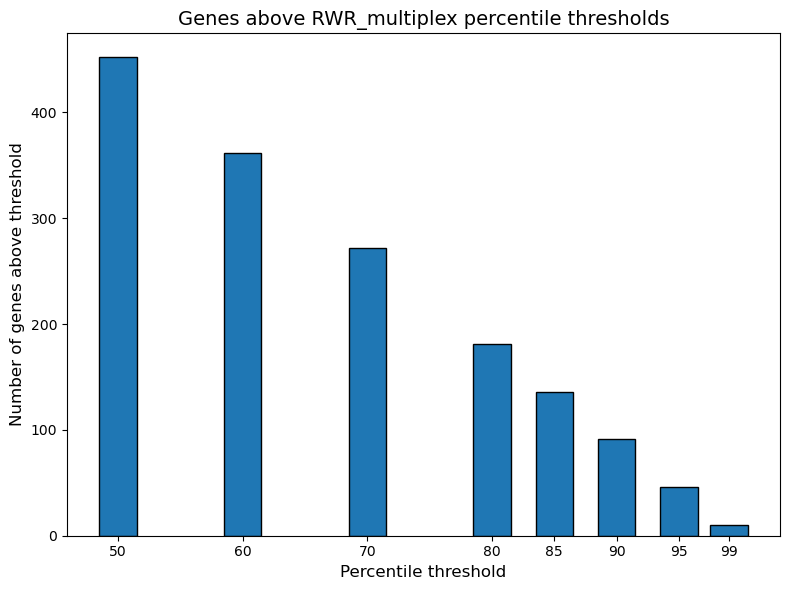

In [33]:
# Define thresholds
percentiles = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.99]
# Compute threshold values
threshold_values = {int(p*100): scores_multiplex['RWR_multiplex'].quantile(p) for p in percentiles}
# Count how many genes are above each threshold
counts = {perc: (scores_multiplex['RWR_multiplex'] > thr).sum() 
          for perc, thr in threshold_values.items()}
# Convert to sorted lists for plotting
x = list(counts.keys())
y = list(counts.values())
# Plot
plt.figure(figsize=(8,6))
plt.bar(x, y, width=3, edgecolor='black')
plt.xlabel("Percentile threshold", fontsize=12)
plt.ylabel("Number of genes above threshold", fontsize=12)
plt.title("Genes above RWR_multiplex percentile thresholds", fontsize=14)
plt.xticks(x)
plt.tight_layout()
plt.show()

In [34]:
#----------------------------
# Saving
#----------------------------
# Merge annotation into scores_multiplex
scores_multiplex_annotated = scores_multiplex.merge(
    clockgenes,
    left_on='Gene',   # column in scores_multiplex
    right_on='Ensembl',  # column in annotation
)

# Optional: drop the redundant 'Ensembl' column
scores_multiplex_annotated = scores_multiplex_annotated.drop(columns=['Ensembl'])
scores_multiplex_annotated_nodup = scores_multiplex_annotated.drop_duplicates(
    subset=['Gene'],  # column(s) to check for duplicates
    keep='first'      # keep the first occurrence
)

#----------------------------
# Saving
#----------------------------
scores_multiplex_annotated_nodup.to_csv('C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/00RWR_clockgenes-08222025.csv',
                        index=False)

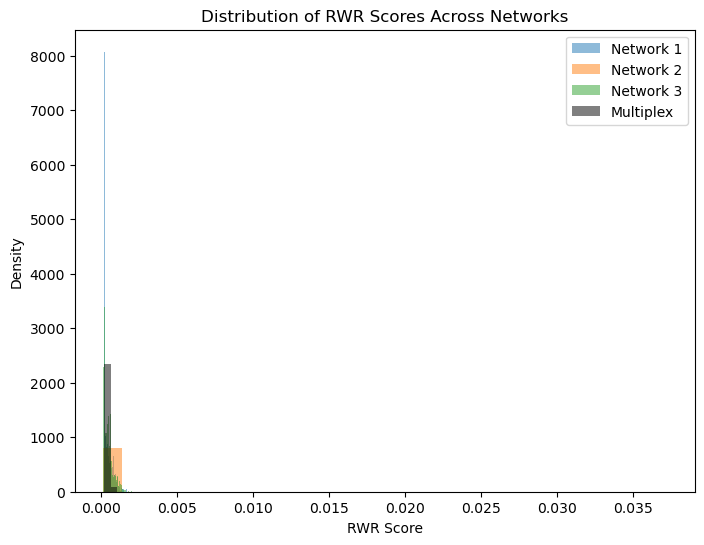

In [35]:
plt.figure(figsize=(8,6))
# Overlay histograms for each network’s RWR scores
plt.hist(scores_multiplex['RWR_layer1'], bins=30, alpha=0.5, label='Network 1', density=True)
plt.hist(scores_multiplex['RWR_layer2'], bins=30, alpha=0.5, label='Network 2', density=True)
plt.hist(scores_multiplex['RWR_layer3'], bins=30, alpha=0.5, label='Network 3', density=True)

# Optional: also plot consensus distribution
plt.hist(scores_multiplex['RWR_multiplex'], bins=30, alpha=0.5, label='Multiplex', density=True, color='black')

plt.xlabel("RWR Score")
plt.ylabel("Density")
plt.title("Distribution of RWR Scores Across Networks")
plt.legend()
plt.show()

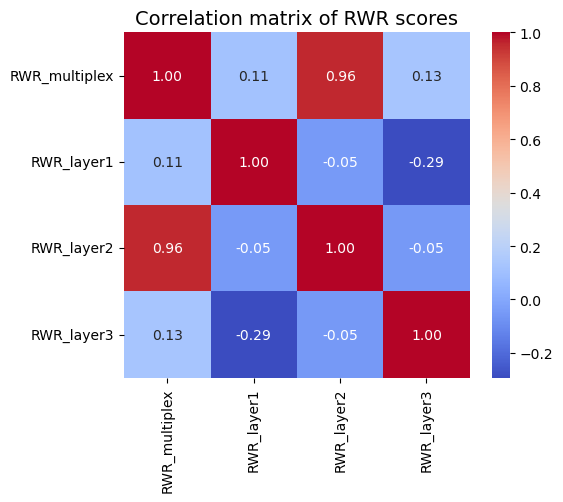

               RWR_multiplex  RWR_layer1  RWR_layer2  RWR_layer3
RWR_multiplex       1.000000    0.114090    0.958499    0.127747
RWR_layer1          0.114090    1.000000   -0.048962   -0.293106
RWR_layer2          0.958499   -0.048962    1.000000   -0.050940
RWR_layer3          0.127747   -0.293106   -0.050940    1.000000


In [36]:
# Compute correlation matrix
corr_matrix = scores_multiplex[['RWR_multiplex','RWR_layer1','RWR_layer2','RWR_layer3']].corr()
# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True, cbar=True)
plt.title("Correlation matrix of RWR scores", fontsize=14)
plt.tight_layout()
plt.show()
# Also print numerical matrix
print(corr_matrix)

In [25]:
# Optionally filter to top 5% genes (to avoid huge network)
df_plot = scores_multiplex_annotated[scores_multiplex_annotated["Top_5_percent"]]

# Create a network: Gene ↔ Clock
G = nx.Graph()

for _, row in df_plot.iterrows():
    gene = row["Gene"]
    clock = row["Clock"]
    score = row["RWR_multiplex"]

    # Add gene node (size scaled by RWR_multiplex)
    G.add_node(gene, 
               size=score * 50000,   # adjust scale for visibility
               node_type="Gene", 
               clock=clock)

    # Add clock node (fixed size, categorical color)
    G.add_node(clock, 
               size=3000, 
               node_type="Clock")

    # Add edge between gene and clock
    G.add_edge(gene, clock)

# Separate nodes
clocks = [n for n, d in G.nodes(data=True) if d["node_type"] == "Clock"]
genes  = [n for n, d in G.nodes(data=True) if d["node_type"] == "Gene"]

# --- Layout ---
pos = {}

# Place clocks evenly spaced on a big circle (outer ring)
angle_step = 2 * np.pi / len(clocks)
radius_outer = 3.0
for i, clock in enumerate(clocks):
    angle = i * angle_step
    pos[clock] = (radius_outer * np.cos(angle), radius_outer * np.sin(angle))

# Place genes with a force-directed layout (smaller radius, inner cloud)
# Start from spring_layout, then shrink positions
inner_pos = nx.spring_layout(G.subgraph(genes), scale=1.0, center=(0, 0))
for gene, p in inner_pos.items():
    pos[gene] = (p[0] * 1.0, p[1] * 1.0)

# --- Draw ---
plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G, pos, alpha=0.2)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=genes,
    node_color=[color_map[G.nodes[g]["clock"]] for g in genes],
    node_size=[G.nodes[g]["size"] for g in genes],
    alpha=0.8
)
nx.draw_networkx_nodes(
    G, pos,
    nodelist=clocks,
    node_color="black",
    node_size=[G.nodes[c]["size"] for c in clocks],
    alpha=0.9
)

# Labels for clocks only
nx.draw_networkx_labels(
    G, pos,
    labels={c: c for c in clocks},
    font_size=12,
    font_color="white",
    font_weight="bold"
)

plt.title("Gene–Clock Network (clocks = outer ring, genes = middle)", fontsize=16)
plt.axis("off")
plt.show()

NameError: name 'scores_multiplex_annotated' is not defined

C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


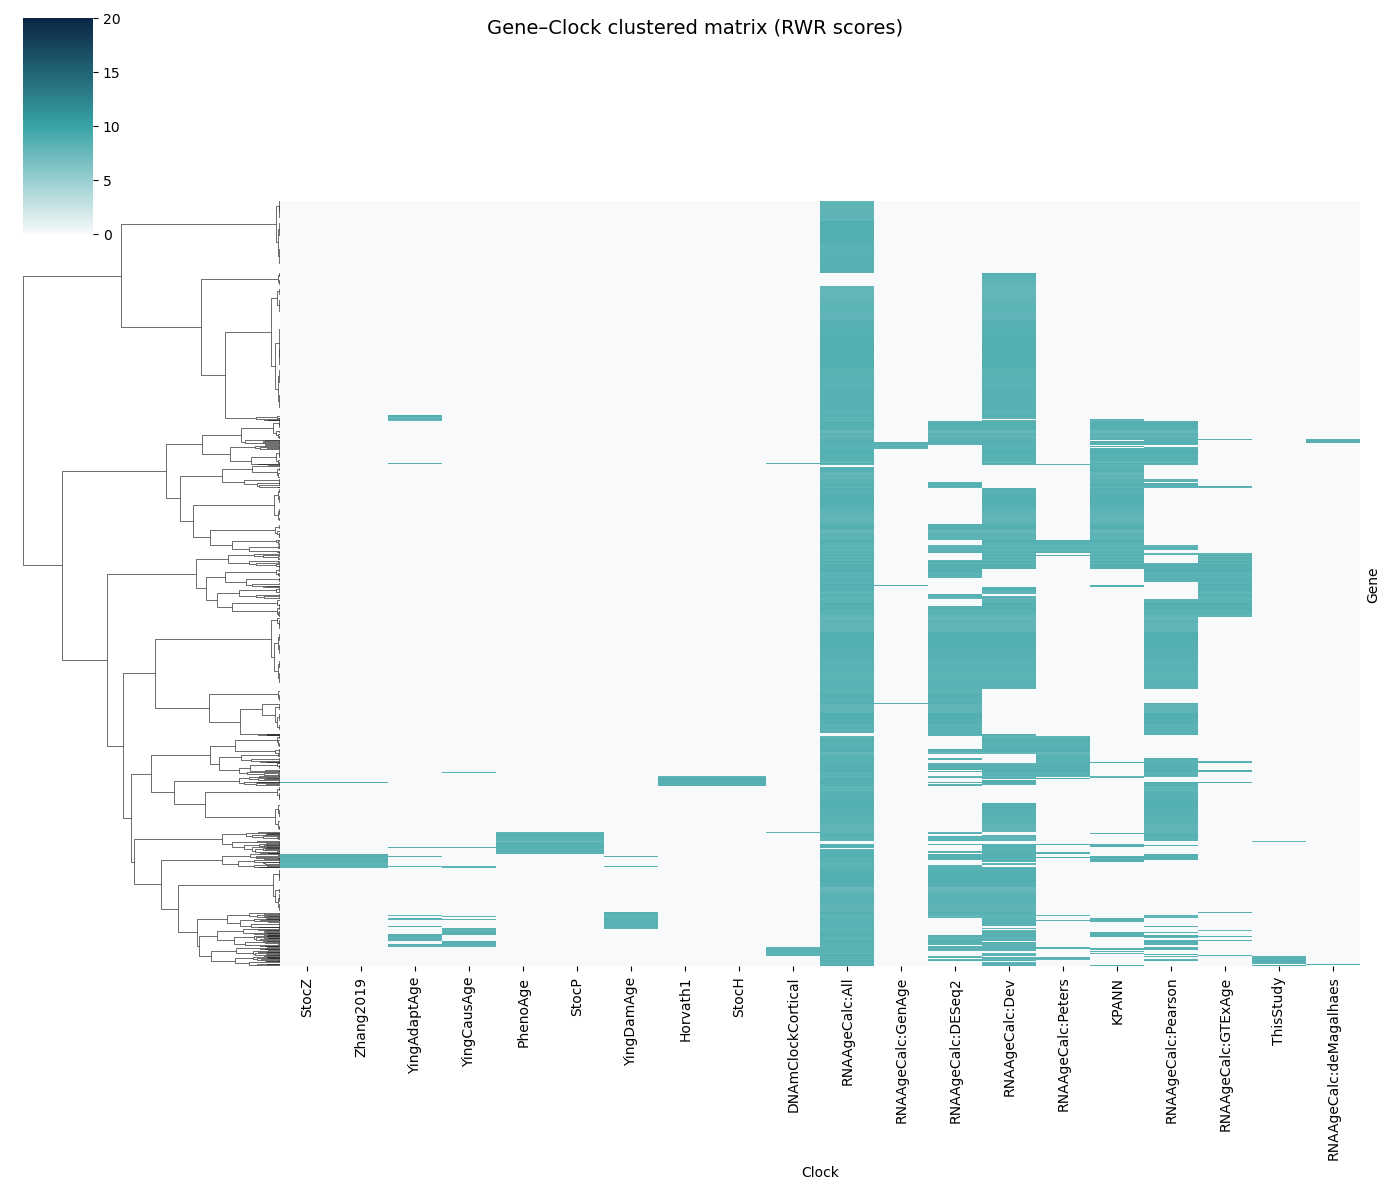

In [69]:
# Start from annotated DataFrame
df = scores_multiplex_annotated.copy()
# Take log of RWR_multiplex
df['RWR_multiplex_log'] = -np.log(df['RWR_multiplex'] + 1e-200)  # tiny offset to avoid log(0)

# Assume you have a DataFrame mapping clocks to their type
# Example: clock_categories = pd.DataFrame({"Clock": [...], "Type": ["Epigenetic", "Transcriptomic", ...]})
clock_categories = df[['Clock', 'Type']].drop_duplicates()

# Create a custom column order: epigenetic first, transcriptomic second
epigenetic_clocks = clock_categories.loc[clock_categories['Type'] == 'Epigenetic', 'Clock'].tolist()
transcriptomic_clocks = clock_categories.loc[clock_categories['Type'] == 'Transcriptome', 'Clock'].tolist()

# Concatenate to get final column order
custom_col_order = epigenetic_clocks + transcriptomic_clocks

# Reorder matrix columns
matrix_ordered = matrix[custom_col_order]

# Clustered heatmap with custom column order
cg = sns.clustermap(
    matrix_ordered,
    method="ward",         
    metric="euclidean",    
    cmap=custom_cmap,      
    figsize=(14, 12),
    xticklabels=True,
    yticklabels=False,
    row_cluster=True,      # cluster genes
    col_cluster=True,      # keep clocks in the specified order
    vmin=0,    # minimum for colormap
    vmax=20    # maximum for colormap
)

# Set title
cg.fig.suptitle("Gene–Clock clustered matrix (RWR scores)", fontsize=14)
plt.show()

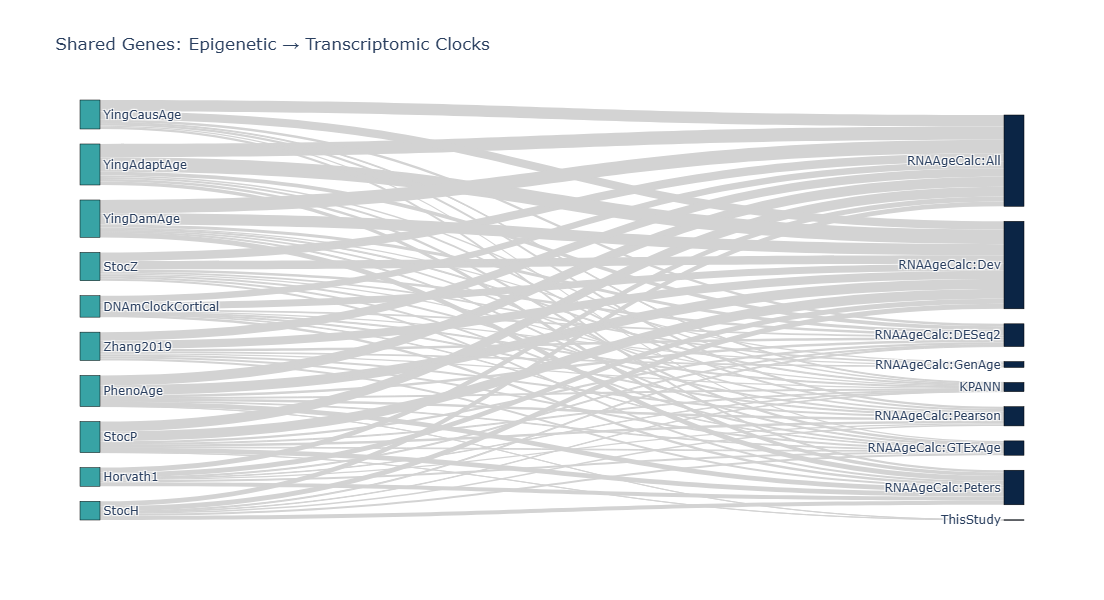

In [84]:
# -------------------------
# Subset by clock type
# -------------------------
epi_df = df[df['Type'] == 'Epigenetic']
trans_df = df[df['Type'] == 'Transcriptome']

# -------------------------
# Create gene → clock mappings
# -------------------------
epi_gene_clock = epi_df.groupby('Gene')['Clock'].apply(list).to_dict()
trans_gene_clock = trans_df.groupby('Gene')['Clock'].apply(list).to_dict()

# -------------------------
# Build links for shared genes
# -------------------------
links = []
for gene in set(epi_gene_clock) & set(trans_gene_clock):
    for epi_clock in epi_gene_clock[gene]:
        for trans_clock in trans_gene_clock[gene]:
            links.append((epi_clock, trans_clock))

link_df = pd.DataFrame(links, columns=['source', 'target'])
link_counts = link_df.groupby(['source', 'target']).size().reset_index(name='weight')

# -------------------------
# Build labels and node order
# -------------------------
epi_clocks = sorted(link_counts['source'].unique())
trans_clocks = sorted(link_counts['target'].unique())
labels = epi_clocks + trans_clocks

sources = link_counts['source'].apply(lambda x: labels.index(x))
targets = link_counts['target'].apply(lambda x: labels.index(x))

# -------------------------
# Plot Sankey
# -------------------------
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color=["#38a3a5"]*len(epi_clocks) + ["#0b2545"]*len(trans_clocks),
        # font is automatically handled; no need to set separately
    ),
    link=dict(
        source=sources,
        target=targets,
        value=link_counts['weight'],
        color="lightgray"
    )
)])

fig.update_layout(
    title_text="Shared Genes: Epigenetic → Transcriptomic Clocks",
    font_size=12,
    width=1000,
    height=600
)

# -------------------------
# Save figure
# -------------------------
# Save as interactive HTML
#fig.write_html("sankey_shared_genes.html")

# Save as static PNG/SVG (requires kaleido)
# pip install kaleido
#fig.write_image("sankey_shared_genes.png", scale=2)
fig.write_image("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/03sankey_shared_genes.pdf")
fig.show()